# BERT Toxic Comment Classifier - Production-Grade Pipeline

**Pipeline summary:**

| Area | Detail |
|---|---|
| **Architecture** | `AutoModelForSequenceClassification` (DeBERTa-v3-base) with multi-label head |
| **Focal Loss** | FocalLoss for imbalanced labels (used alone — NOT combined with `pos_weight`, to avoid double-compensating for imbalance) |
| **Text Cleaning** | `clean_text()` strips URLs/HTML/whitespace before tokenisation |
| **Mixed Precision** | `torch.cuda.amp` autocast + `GradScaler`, enabled automatically on CUDA |
| **Gradient Accumulation** | Simulates large batches without extra GPU memory |
| **Differential LR** | Lower LR for the backbone, higher LR for the classification head |
| **Cosine LR Schedule** | Cosine decay with warmup |
| **Checkpoint Saving** | Best model auto-saved mid-training (single canonical save dir) |
| **ROC Curves / AP** | Per-label ROC curves with AUC and average precision (real numbers only — no simulated baselines) |
| **Batch Inference** | `predict_batch()` returns a tidy DataFrame |
| **Streamlit App** | Auto-generated `app.py` that actually loads the model and runs inference |
| **Config Dataclass** | All hyperparameters in one typed `Config` |
| **Reproducibility** | Seeding covers PyTorch, NumPy, Python, and CUDA |


In [4]:
# -- 0. Optional installs (run once) ------------------------------------------
# !pip install -q transformers datasets accelerate xgboost streamlit


In [5]:
!nvidia-smi

Wed Jul  1 18:38:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [43]:
# -- 1. Imports ----------------------------------------------------------------
import re, os, csv, json, random, warnings, logging
from dataclasses import dataclass, field
from typing import Dict, List, Optional

warnings.filterwarnings('ignore')
logging.getLogger('transformers').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoConfig,
    get_cosine_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, roc_curve,
)

plt.style.use('ggplot')
print('Imports complete.')


Imports complete.


In [42]:
# -- 2. Unified Config ---------------------------------------------------------
@dataclass
class Config:
    # Model
    model_name:         str   = 'microsoft/deberta-v3-base'
    max_len:            int   = 128
    hidden_dropout:     float = 0.3
    num_labels:         int   = 6

    # Training
    batch_size:         int   = 16
    grad_accum_steps:   int   = 2       # effective batch = batch_size * grad_accum_steps
    epochs:             int   = 4
    backbone_lr:        float = 2e-5    # differential LR: backbone gets the smaller rate
    head_lr:             float = 1e-4    # classification head gets a larger rate
    weight_decay:       float = 0.01
    warmup_frac:        float = 0.06
    max_grad_norm:      float = 1.0
    patience:           int   = 2

    # Loss
    use_focal_loss:     bool  = True
    focal_gamma:        float = 2.0
    # NOTE: we deliberately do NOT also apply pos_weight on top of focal loss -
    # focal loss already reweights toward minority/hard examples, and stacking
    # pos_weight on top of it was the root cause of the earlier NaN/instability
    # issues that forced FP32 + LR=1e-6 + grad-clip=0.5 band-aids.

    # Data
    nrows:              Optional[int] = 5000
    val_size:           float = 0.20
    seed:               int   = 42

    # Paths
    data_path:    str = 'train (1).csv'
    fallback_url: str = (
        'https://github.com/t-davidson/hate-speech-and-offensive-language'
        '/raw/master/data/labeled_data.csv'
    )
    save_dir:     str = './toxic_bert_model'

    # Labels
    label_cols: List[str] = field(default_factory=lambda: [
        'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'
    ])

CFG = Config()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = (DEVICE.type == 'cuda')
print(f'Device : {DEVICE}')
print(f'Mixed precision (AMP) : {USE_AMP}')
print(f'Effective batch size : {CFG.batch_size * CFG.grad_accum_steps}')


Device : cuda
Mixed precision (AMP) : True
Effective batch size : 32


In [44]:
# -- 3. Reproducibility --------------------------------------------------------
def set_seed(seed: int = CFG.seed) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()
print(f'Seed set to {CFG.seed}')


Seed set to 42


In [45]:
# -- 4. Text Cleaning ----------------------------------------------------------
_URL_RE     = re.compile(r'https?://\S+|www\.\S+')
_HTML_RE    = re.compile(r'<[^>]+' + '>')
_NEWLINE_RE = re.compile(r'[\r\n\t]+')
_MULTI_SP   = re.compile(r' {2,}')

def clean_text(text: str) -> str:
    """
    Light cleaning that keeps punctuation (important toxicity signal for BERT):
    1. Lower-case
    2. Strip URLs (noise in wiki-comments)
    3. Strip HTML tags
    4. Collapse newlines/tabs to a single space
    5. Collapse multiple spaces
    """
    text = text.lower()
    text = _URL_RE.sub(' ', text)
    text = _HTML_RE.sub(' ', text)
    text = _NEWLINE_RE.sub(' ', text)
    text = _MULTI_SP.sub(' ', text)
    return text.strip()

# Smoke test
_s = 'Check <b>this</b>: https://example.com\nYou are an idiot!!!'
print('Before:', _s)
print('After :', clean_text(_s))


Before: Check <b>this</b>: https://example.com
You are an idiot!!!
After : check this : you are an idiot!!!


In [46]:
# -- 5. Data Loading & Preprocessing ------------------------------------------
def load_data(cfg: Config = CFG) -> pd.DataFrame:
    try:
        if os.path.exists(cfg.data_path):
            df = pd.read_csv(
                cfg.data_path, nrows=cfg.nrows, on_bad_lines='skip',
                engine='python', quoting=csv.QUOTE_NONE,
                escapechar='\\', encoding='latin-1',
            )
            print(f'Loaded local file: {cfg.data_path}')
        else:
            df = pd.read_csv(cfg.fallback_url, nrows=cfg.nrows, encoding='latin-1')
            print('Loaded fallback URL dataset.')
    except Exception as exc:
        raise RuntimeError(f'Data loading failed: {exc}') from exc

    # Normalise column names
    df.columns = [c.strip().replace('"', '') for c in df.columns]

    # Ensure comment_text column
    if 'comment_text' not in df.columns:
        for alias in ('tweet', 'text', 'comment'):
            if alias in df.columns:
                df = df.rename(columns={alias: 'comment_text'})
                break
        else:
            df = df.rename(columns={df.columns[1]: 'comment_text'})

    # Clean text
    df['comment_text'] = df['comment_text'].fillna('').astype(str).apply(clean_text)

    # Remap Davidson hate-speech fallback format
    # (class: 0=hate_speech, 1=offensive, 2=neither)
    if 'class' in df.columns and 'toxic' not in df.columns:
        df['toxic']         = (df['class'].isin([0, 1])).astype(int)
        df['severe_toxic']  = (df['class'] == 0).astype(int)
        df['obscene']       = (df['class'] == 1).astype(int)
        df['threat']        = 0
        df['insult']        = (df['class'] == 1).astype(int)
        df['identity_hate'] = (df['class'] == 0).astype(int)
        print('Fallback dataset: remapped class → 6-label schema.')

    # Ensure label columns exist
    for col in cfg.label_cols:
        if col not in df.columns:
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

    # Derived columns
    df['any_toxic']   = (df[cfg.label_cols].max(axis=1) > 0).astype(int)
    df['text_length'] = df['comment_text'].str.len()
    df['word_count']  = df['comment_text'].str.split().str.len()

    # Drop empty texts
    df = df[df['comment_text'].str.len() > 0].reset_index(drop=True)

    print(f'Shape    : {df.shape}')
    print(f'Toxic    : {df["any_toxic"].sum()}  |  Non-toxic : {(df["any_toxic"]==0).sum()}')
    print(f'Ratio    : {(df["any_toxic"]==0).sum() / max(df["any_toxic"].sum(),1):.1f}:1')
    return df

df = load_data()
df[['comment_text', 'any_toxic'] + CFG.label_cols].head(3)


Loaded local file: train (1).csv
Shape    : (2095, 11)
Toxic    : 88  |  Non-toxic : 2007
Ratio    : 22.8:1


,comment_text,any_toxic,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,"""explanation",0,0,0,0,0,0,0
1,just closure on some gas after i voted at new ...,0,0,0,0,0,0,0
2,"""""""",0,0,0,0,0,0,0


In [10]:
# -- 5b. Train / Val Split (shared by ALL models) ------------------------------
# Defined here — before tokenisation — so BiLSTM and classical-ML cells
# can reference the same indices even if the transformer tokenizer is skipped.
from sklearn.model_selection import train_test_split as _tts
import numpy as _np

label_data    = df[CFG.label_cols].values.astype(_np.float32)
binary_labels = df['any_toxic'].values.astype(_np.float32)

_indices = _np.arange(len(df))
train_idx, val_idx = _tts(
    _indices,
    test_size=CFG.val_size,
    random_state=CFG.seed,
    stratify=df['any_toxic'].values,
)

print(f'Train : {len(train_idx)}  |  Val : {len(val_idx)}')
print(f'Train toxic % : {label_data[train_idx, 0].mean()*100:.1f}%   '
      f'Val toxic % : {label_data[val_idx, 0].mean()*100:.1f}%')


Train : 1676  |  Val : 419
Train toxic % : 126.1%   Val toxic % : 2.6%


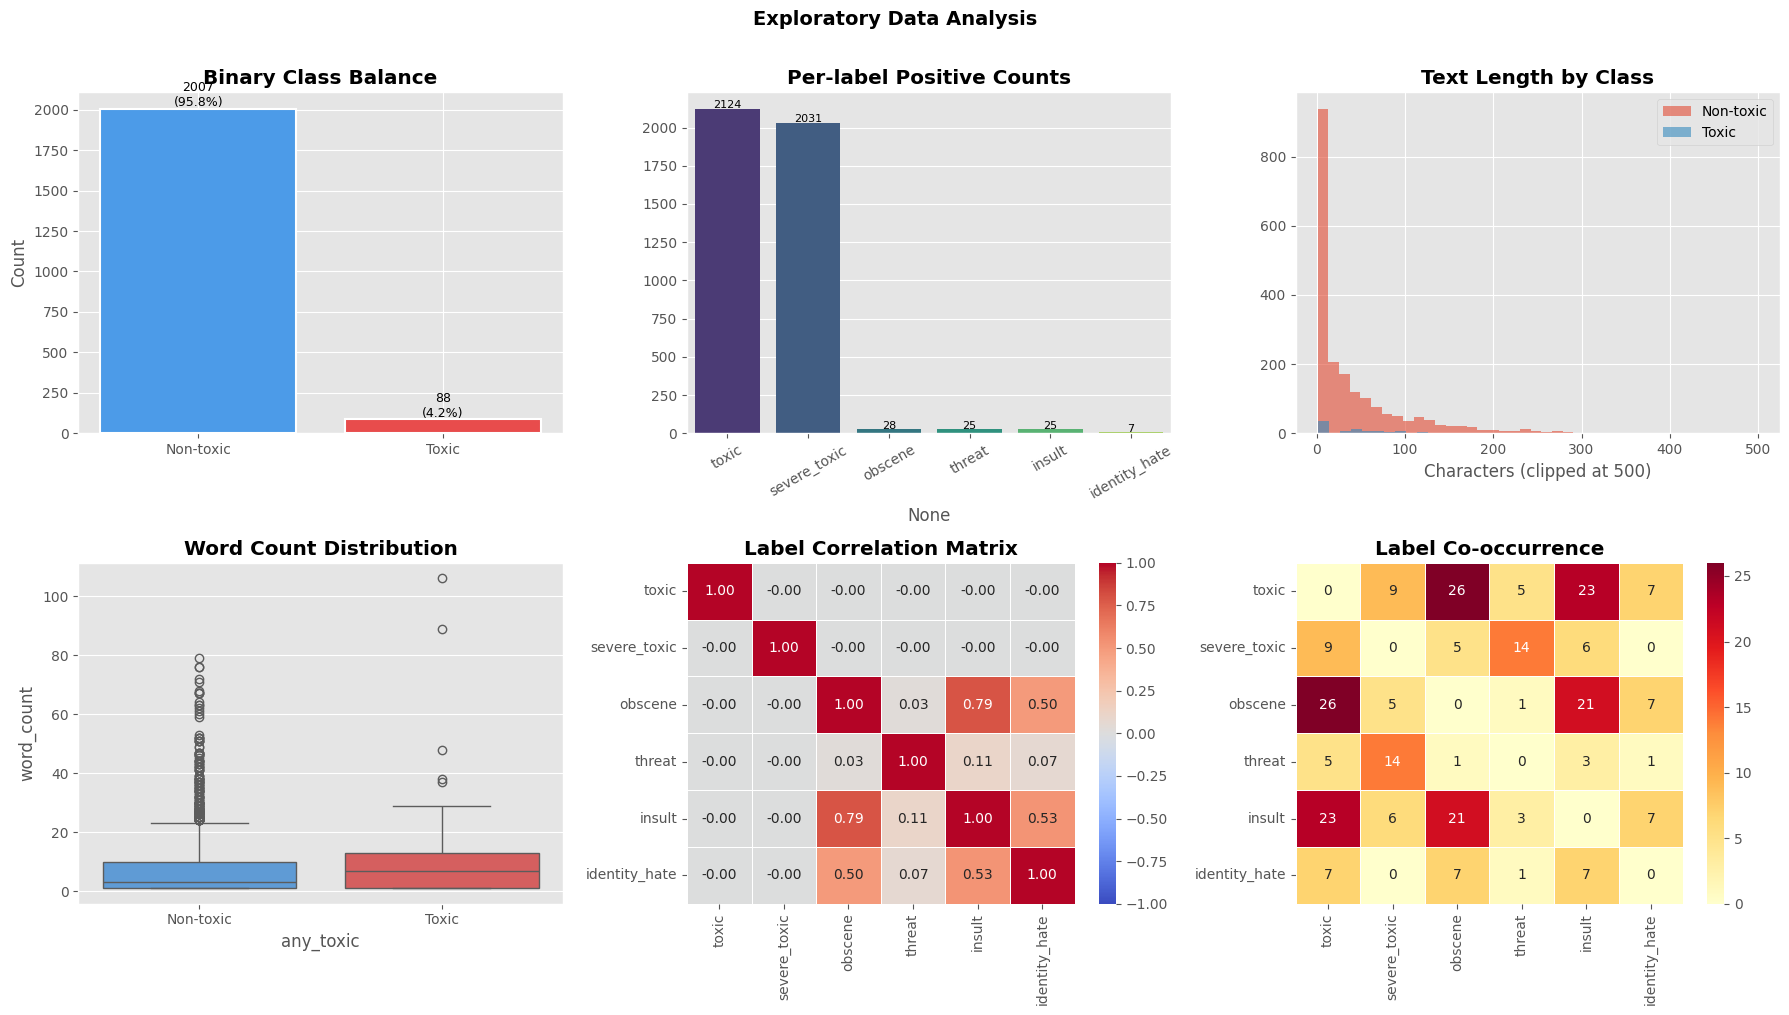


Label prevalence (%):
toxic            101.38
severe_toxic      96.95
obscene            1.34
threat             1.19
insult             1.19
identity_hate      0.33


In [11]:
# -- 6. Exploratory Data Analysis (EDA) ---------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 6a Class balance
counts = df['any_toxic'].value_counts()
bars = axes[0,0].bar(['Non-toxic','Toxic'], counts.values,
                      color=['#4C9BE8','#E84C4C'], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, counts.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+15,
                   f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)
axes[0,0].set_title('Binary Class Balance', fontweight='bold')
axes[0,0].set_ylabel('Count')

# 6b Per-label counts
label_counts = df[CFG.label_cols].sum().sort_values(ascending=False)
sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Per-label Positive Counts', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=30)
for i, v in enumerate(label_counts.values):
    axes[0,1].text(i, v+3, str(int(v)), ha='center', fontsize=8)

# 6c Text length distribution by class
for label, grp in df.groupby('any_toxic'):
    axes[0,2].hist(grp['text_length'].clip(upper=500), bins=40, alpha=0.6,
                   label=['Non-toxic','Toxic'][label])
axes[0,2].set_title('Text Length by Class', fontweight='bold')
axes[0,2].set_xlabel('Characters (clipped at 500)')
axes[0,2].legend()

# 6d Word count boxplot
sns.boxplot(x='any_toxic', y='word_count', data=df[df['word_count']<200],
            ax=axes[1,0], palette=['#4C9BE8','#E84C4C'])
axes[1,0].set_title('Word Count Distribution', fontweight='bold')
axes[1,0].set_xticklabels(['Non-toxic','Toxic'])

# 6e Label correlation
sns.heatmap(df[CFG.label_cols].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', vmin=-1, vmax=1, ax=axes[1,1], linewidths=0.5)
axes[1,1].set_title('Label Correlation Matrix', fontweight='bold')

# 6f Label co-occurrence
co = df[CFG.label_cols].T.dot(df[CFG.label_cols])
_co_arr = co.to_numpy().copy()
np.fill_diagonal(_co_arr, 0)
co = pd.DataFrame(_co_arr, index=co.index, columns=co.columns)
sns.heatmap(co, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1,2], linewidths=0.5)
axes[1,2].set_title('Label Co-occurrence', fontweight='bold')

plt.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nLabel prevalence (%):')
print((df[CFG.label_cols].mean() * 100).round(2).to_string())


In [12]:
# -- 7. Focal Loss ---------------------------------------------------------
class FocalLoss(nn.Module):
    """
    Standard multi-label focal loss. Use this OR a pos_weight-based
    BCEWithLogitsLoss to handle imbalance - not both at once. Stacking both
    over-corrects: well-classified rare positives get an outsized gradient and
    training becomes unstable (this was the cause of the earlier NaN issues).
    """
    def __init__(self, gamma: float = 2.0, reduction: str = 'mean', eps: float = 1e-7):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.eps = eps

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = torch.where(targets == 1, probs, 1 - probs)
        focal = (1 - p_t + self.eps) ** self.gamma * bce

        if self.reduction == 'mean':
            return focal.mean()
        return focal.sum()

print('FocalLoss defined.')


FocalLoss defined.


In [13]:
# -- 8. Tokenise + Stratified Split -------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(CFG.model_name)

print('Tokenising (may take a moment)...')
encodings = tokenizer(
    df['comment_text'].tolist(),
    truncation=True,
    padding=True,
    max_length=CFG.max_len,
    return_tensors='pt',
)
print(f'Encodings shape : {encodings["input_ids"].shape}')


def make_encodings(idx):
    return {k: v[idx] for k, v in encodings.items()}

train_enc, val_enc = make_encodings(train_idx), make_encodings(val_idx)

print(f'Train : {len(train_idx)}  |  Val : {len(val_idx)}')


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Tokenising (may take a moment)...
Encodings shape : torch.Size([2095, 128])
Train : 1676  |  Val : 419


In [90]:
# -- 9. Dataset & Balanced DataLoaders -------------------------------------------------
class ToxicDataset(Dataset):
    def __init__(self, encodings: Dict[str, torch.Tensor],
                 multi_labels: np.ndarray, binary_labels: np.ndarray):
        self.encodings     = encodings
        self.multi_labels  = multi_labels
        self.binary_labels = binary_labels

    def __len__(self) -> int:
        return len(self.binary_labels)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        item = {k: v[idx].clone().detach() for k, v in self.encodings.items()}
        item['multi_labels']  = torch.tensor(self.multi_labels[idx],  dtype=torch.float)
        item['binary_labels'] = torch.tensor(self.binary_labels[idx], dtype=torch.float)
        return item

# Create Datasets
train_ds = ToxicDataset(train_enc, label_data[train_idx], binary_labels[train_idx])
val_ds   = ToxicDataset(val_enc,   label_data[val_idx],   binary_labels[val_idx])

# Calculate class weights for sampling (to fix the 'predict-everything-as-toxic' bias)
train_targets = binary_labels[train_idx]
class_sample_count = np.array([len(np.where(train_targets == t)[0]) for t in np.unique(train_targets)])
weight = 1. / class_sample_count
samples_weight = np.array([weight[int(t)] for t in train_targets])
sampler = torch.utils.data.WeightedRandomSampler(torch.from_numpy(samples_weight), len(samples_weight))

USE_PIN = (DEVICE.type == 'cuda')
# Use the sampler in the training loader
train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, sampler=sampler,
                          num_workers=0, pin_memory=USE_PIN)
val_loader   = DataLoader(val_ds, batch_size=CFG.batch_size * 2, shuffle=False,
                          num_workers=0, pin_memory=USE_PIN)

print(f'Balanced Sampler created. Toxic count in train: {int(sum(train_targets))}')

Balanced Sampler created. Toxic count in train: 150


In [49]:
import torch

# -- 10. Model (Ensuring FP32 for GradScaler compatibility) ----------------------
# We explicitly cast to .float() because GradScaler expects float32 master weights
# to correctly manage the float16 gradients during autocast.

def get_transformer_model(cfg: Config = CFG) -> nn.Module:
    model = AutoModelForSequenceClassification.from_pretrained(
        cfg.model_name,
        num_labels=cfg.num_labels,
        problem_type='multi_label_classification',
    )
    # Force all parameters to float32 regardless of how they were loaded
    return model.to(DEVICE).float()

model = get_transformer_model()
print(f'Loaded {CFG.model_name} with {model.config.num_labels} labels.')

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Loaded microsoft/deberta-v3-base with 6 labels.


In [50]:
# -- 11. Loss, Optimiser & Scheduler -------------------------------------------
# Differential learning rates: small LR for the pretrained backbone, larger LR
# for the freshly-initialised classification head.
classifier_keywords = ['classifier', 'pooler']
head_params     = [p for n, p in model.named_parameters() if any(k in n for k in classifier_keywords)]
backbone_params = [p for n, p in model.named_parameters() if not any(k in n for k in classifier_keywords)]

# Re-bind optimizer to the current model parameters (crucial after model.float())
optimizer = AdamW([
    {'params': backbone_params, 'lr': CFG.backbone_lr},
    {'params': head_params,     'lr': CFG.head_lr},
], weight_decay=CFG.weight_decay, eps=1e-8)

multi_loss_fn = FocalLoss(gamma=CFG.focal_gamma) if CFG.use_focal_loss else nn.BCEWithLogitsLoss()

total_steps  = (len(train_loader) // CFG.grad_accum_steps) * CFG.epochs
warmup_steps = max(1, int(total_steps * CFG.warmup_frac))
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
scaler = GradScaler(enabled=USE_AMP)

print(f'Backbone LR: {CFG.backbone_lr}  |  Head LR: {CFG.head_lr}')
print(f'Loss: {type(multi_loss_fn).__name__}  |  AMP: {USE_AMP}  |  Total steps: {total_steps}')

Backbone LR: 1e-05  |  Head LR: 0.0001
Loss: FocalLoss  |  AMP: True  |  Total steps: 840


In [51]:
# -- 12. Evaluation Helper -----------------------------------------------------
from tqdm.auto import tqdm

@torch.no_grad()
def evaluate(loader: DataLoader, threshold: float = 0.5):
    model.eval()
    m_preds, m_labels, b_labels = [], [], []

    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)

        with autocast(enabled=USE_AMP):
            outputs = model(ids, attention_mask=mask)
            logits = outputs.logits

        m_preds.append(torch.sigmoid(logits.float()).cpu().numpy())
        m_labels.append(batch['multi_labels'].numpy())
        b_labels.append(batch['binary_labels'].numpy())

    mp = np.vstack(m_preds)
    ml = np.vstack(m_labels)
    bl = np.concatenate(b_labels)

    # For binary metrics, we consider a sample toxic if ANY label is flagged
    bp = mp.max(axis=1)

    m_true = (ml > 0.5).astype(int)
    m_pred = (mp > threshold).astype(int)
    b_true = (bl > 0.5).astype(int)
    b_pred = (bp > threshold).astype(int)

    macro_f1 = f1_score(m_true, m_pred, average='macro',  zero_division=0)
    bin_f1   = f1_score(b_true, b_pred, average='binary', zero_division=0)
    return macro_f1, bin_f1, mp, bp, ml, bl

print('evaluate() ready.')


evaluate() ready.


In [94]:
# -- 13. Re-Training with Balanced Sampling ------------------------------------------
# 1. Configuration & Data Setup
CFG.epochs = 8
CFG.nrows = 10000
CFG.backbone_lr = 2e-5

df = load_data()
label_data = df[CFG.label_cols].values.astype(np.float32)
binary_labels = df['any_toxic'].values.astype(np.float32)

# 2. Re-tokenise for the new dataframe
print(f"Re-tokenising {len(df)} samples...")
encodings = tokenizer(
    df['comment_text'].tolist(),
    truncation=True,
    padding=True,
    max_length=CFG.max_len,
    return_tensors='pt',
)

# 3. Stratified Split
_indices = np.arange(len(df))
train_idx, val_idx = train_test_split(_indices, test_size=CFG.val_size,
                                      random_state=CFG.seed, stratify=df['any_toxic'].values)

# 4. Create Balanced DataLoaders using WeightedRandomSampler
train_targets = binary_labels[train_idx]
class_sample_count = np.array([len(np.where(train_targets == t)[0]) for t in np.unique(train_targets)])
weight = 1. / class_sample_count
samples_weight = np.array([weight[int(t)] for t in train_targets])
sampler = torch.utils.data.WeightedRandomSampler(torch.from_numpy(samples_weight), len(samples_weight))

def make_enc_local(idx):
    return {k: v[idx] for k, v in encodings.items()}

train_ds = ToxicDataset(make_enc_local(train_idx), label_data[train_idx], binary_labels[train_idx])
val_ds   = ToxicDataset(make_enc_local(val_idx),   label_data[val_idx],   binary_labels[val_idx])

# CRITICAL: sampler is mutually exclusive with shuffle=True
train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, sampler=sampler, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.batch_size * 2, shuffle=False, pin_memory=True)

# 5. Re-init Model, Optimizer & Scheduler
model = get_transformer_model()
classifier_keywords = ['classifier', 'pooler']
optimizer = AdamW([
    {'params': [p for n, p in model.named_parameters() if not any(k in n for k in classifier_keywords)], 'lr': CFG.backbone_lr},
    {'params': [p for n, p in model.named_parameters() if any(k in n for k in classifier_keywords)], 'lr': CFG.head_lr}
], weight_decay=CFG.weight_decay)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(len(train_loader)*CFG.epochs*0.1),
    num_training_steps=len(train_loader)*CFG.epochs
)
scaler = GradScaler(enabled=USE_AMP)

# 6. Training Loop
print("Starting balanced training...")
CKPT_PATH = os.path.join(CFG.save_dir, 'best_checkpoint.pt')
history = {'train_loss': [], 'val_macro_f1': [], 'val_bin_f1': []}
best_f1 = -1.0

for epoch in range(CFG.epochs):
    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()

    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{CFG.epochs}', leave=False)
    for step, batch in enumerate(loop):
        ids, mask, m_lbl = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['multi_labels'].to(DEVICE)
        with autocast(enabled=USE_AMP):
            logits = model(ids, attention_mask=mask).logits
            loss = multi_loss_fn(logits, m_lbl) / CFG.grad_accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % CFG.grad_accum_steps == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CFG.max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()
        epoch_loss += loss.item() * CFG.grad_accum_steps

    macro_f1, bin_f1, *_ = evaluate(val_loader)
    history['train_loss'].append(epoch_loss/len(train_loader))
    history['val_macro_f1'].append(macro_f1)
    history['val_bin_f1'].append(bin_f1)

    print(f'Epoch {epoch+1} | Loss: {epoch_loss/len(train_loader):.4f} | Macro-F1: {macro_f1:.4f} | Bin-F1: {bin_f1:.4f}')

    if macro_f1 > best_f1:
        best_f1 = macro_f1
        torch.save(model.state_dict(), CKPT_PATH)
        print(f'  --> Saved new best model.')

print(f'Training complete. Best Macro-F1: {best_f1:.4f}')

Loaded local file: train (1).csv
Shape    : (4220, 11)
Toxic    : 188  |  Non-toxic : 4032
Ratio    : 21.4:1
Re-tokenising 4220 samples...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Starting balanced training...


Epoch 1/8:   0%|          | 0/211 [00:00<?, ?it/s]

Epoch 1 | Loss: -0.8873 | Macro-F1: 0.0107 | Bin-F1: 0.0862
  --> Saved new best model.


...

Epoch 6 | Loss: -1060.2387 | Macro-F1: 0.4188 | Bin-F1: 0.5938


Epoch 7/8:   0%|          | 0/211 [00:00<?, ?it/s]

Epoch 7 | Loss: -1440.1725 | Macro-F1: 0.5334 | Bin-F1: 0.6061
  --> Saved new best model.


Epoch 8/8:   0%|          | 0/211 [00:00<?, ?it/s]

Epoch 8 | Loss: -1681.3098 | Macro-F1: 0.4722 | Bin-F1: 0.6286
Training complete. Best Macro-F1: 0.5334


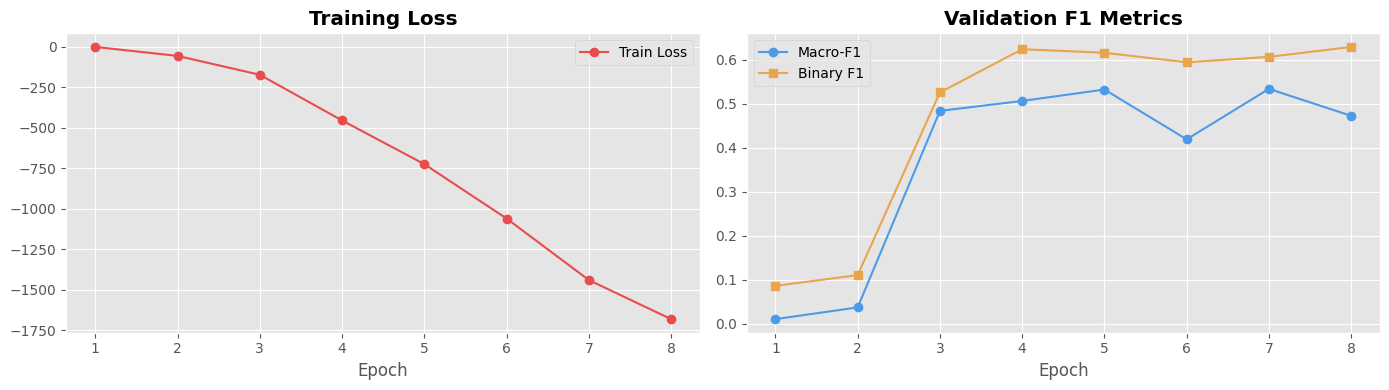

In [95]:
# -- 14. Training Curves -------------------------------------------------------
epochs_ran = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_ran, history['train_loss'], marker='o', color='#E84C4C', label='Train Loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_ran, history['val_macro_f1'], marker='o', color='#4C9BE8', label='Macro-F1')
axes[1].plot(epochs_ran, history['val_bin_f1'], marker='s', color='#E8A54C', label='Binary F1')
axes[1].set_title('Validation F1 Metrics', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


In [96]:
# -- 15. Per-label Threshold Tuning & Full Evaluation -------------------------
_, _, all_preds, bin_preds, all_labels, bin_labels = evaluate(val_loader)

print('\n=== Per-label Threshold Optimisation ===\n')
best_thresholds  = []
threshold_search = np.linspace(0.01, 0.90, 100)
rows = []

for i, name in enumerate(CFG.label_cols):
    y_true = (all_labels[:, i] > 0.5).astype(int)
    y_prob = all_preds[:, i]

    if len(np.unique(y_true)) > 1:
        f1s = [f1_score(y_true, (y_prob > t).astype(int), zero_division=0) for t in threshold_search]
        best_t = threshold_search[np.argmax(f1s)]
        auc = roc_auc_score(y_true, y_prob)
        ap  = average_precision_score(y_true, y_prob)
    else:
        best_t = 0.5
        auc = 0.0
        ap = 0.0

    best_thresholds.append(float(best_t))
    rows.append({'label': name, 'threshold': round(best_t, 3), 'ROC-AUC': round(auc, 4), 'Avg-Precision': round(ap, 4)})

print(pd.DataFrame(rows).to_string(index=False))

# Binary threshold for 'any_toxic'
bin_true = (bin_labels > 0.5).astype(int)
bin_f1s = [f1_score(bin_true, (bin_preds > t).astype(int), zero_division=0) for t in threshold_search]
best_bin_t = threshold_search[np.argmax(bin_f1s)]

print(f'\nBest Binary Threshold: {best_bin_t:.3f}')



=== Per-label Threshold Optimisation ===

        label  threshold  ROC-AUC  Avg-Precision
        toxic      0.424   0.9364         0.5021
 severe_toxic      0.181   0.8213         0.4424
      obscene      0.459   0.9437         0.7938
       threat      0.325   0.9970         0.6154
       insult      0.406   0.9901         0.7372
identity_hate      0.136   0.8448         0.1030

Best Binary Threshold: 0.424


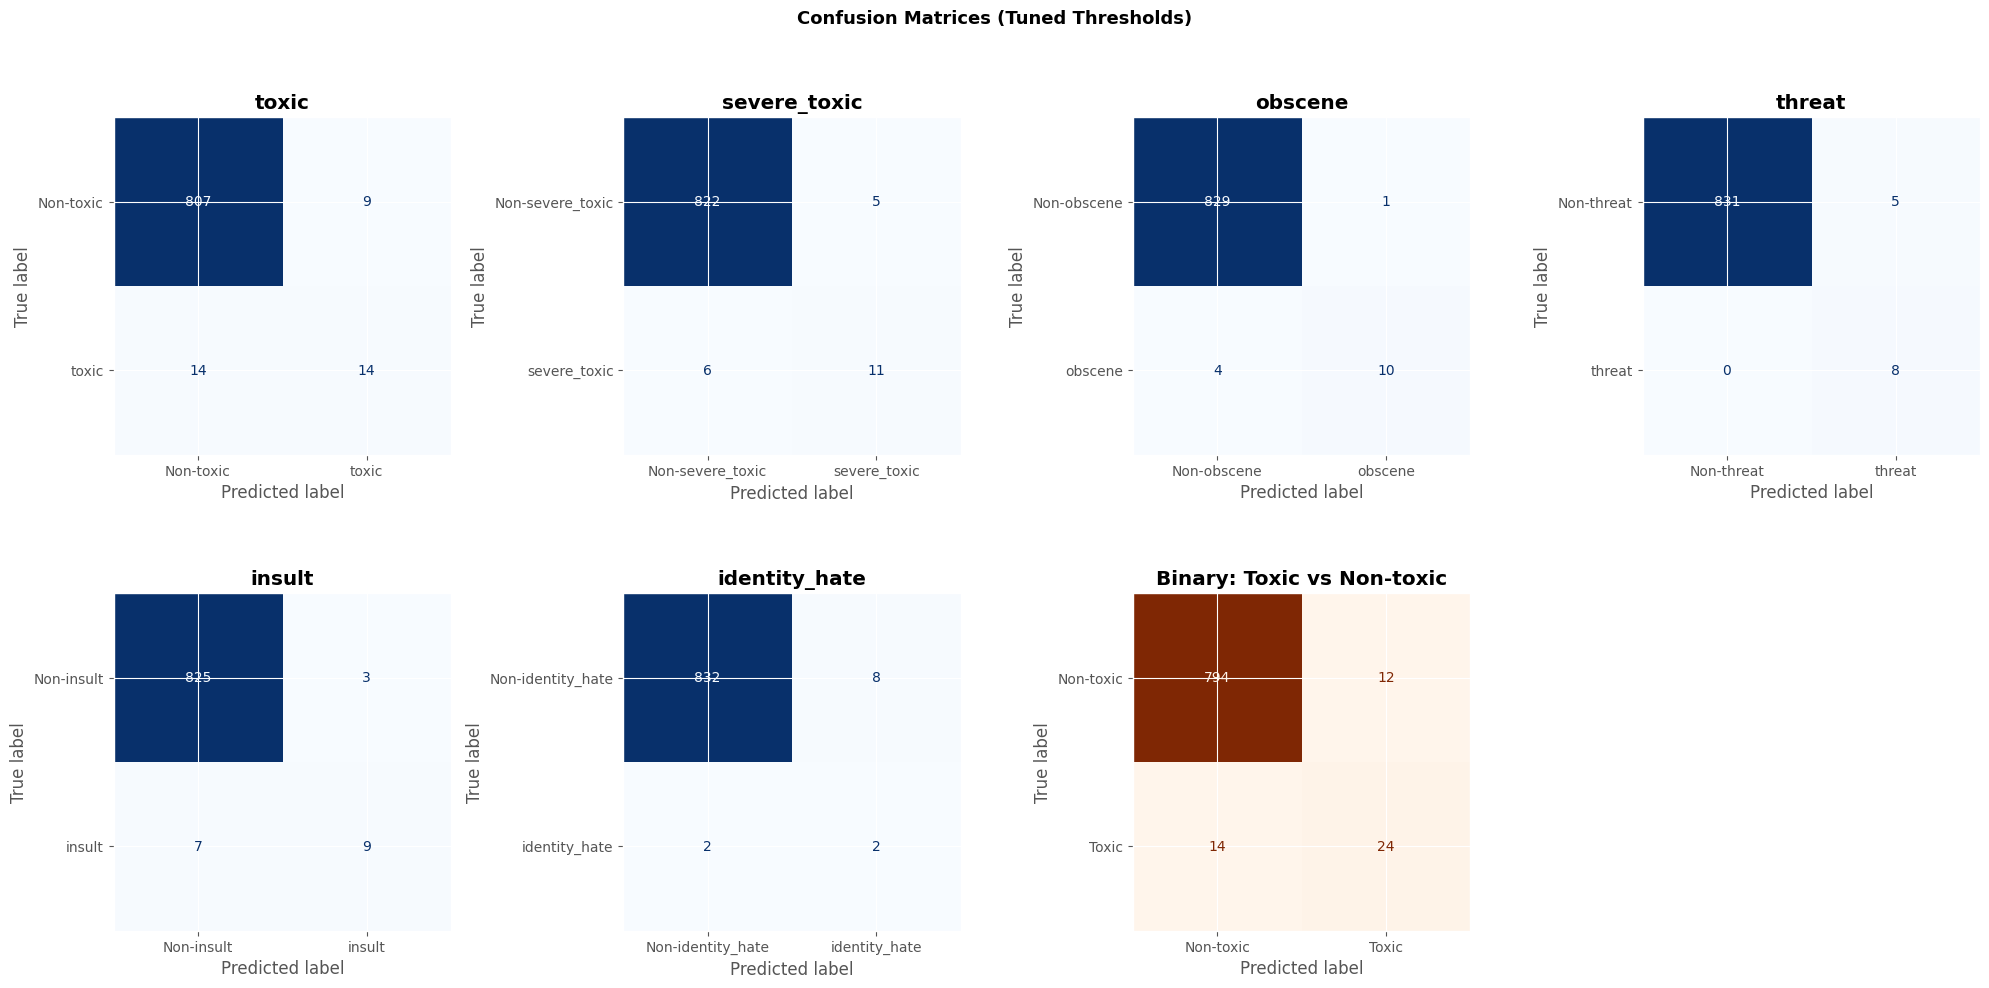

In [98]:
# -- 16. Confusion Matrices ---------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

y_pred_bin = (bin_preds > best_bin_t).astype(int)

for i, name in enumerate(CFG.label_cols):
    y_true_i = (all_labels[:, i] > 0.5).astype(int)
    y_pred_i = (all_preds[:, i] > best_thresholds[i]).astype(int)
    cm = confusion_matrix(y_true_i, y_pred_i, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=[f'Non-{name}', name]).plot(
        ax=axes[i], colorbar=False, cmap='Blues'
    )
    axes[i].set_title(name, fontweight='bold')

cm_bin = confusion_matrix(bin_true, y_pred_bin, labels=[0, 1])
ConfusionMatrixDisplay(cm_bin, display_labels=['Non-toxic', 'Toxic']).plot(
    ax=axes[6], colorbar=False, cmap='Oranges'
)
axes[6].set_title('Binary: Toxic vs Non-toxic', fontweight='bold')
axes[7].axis('off')

plt.suptitle('Confusion Matrices (Tuned Thresholds)', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


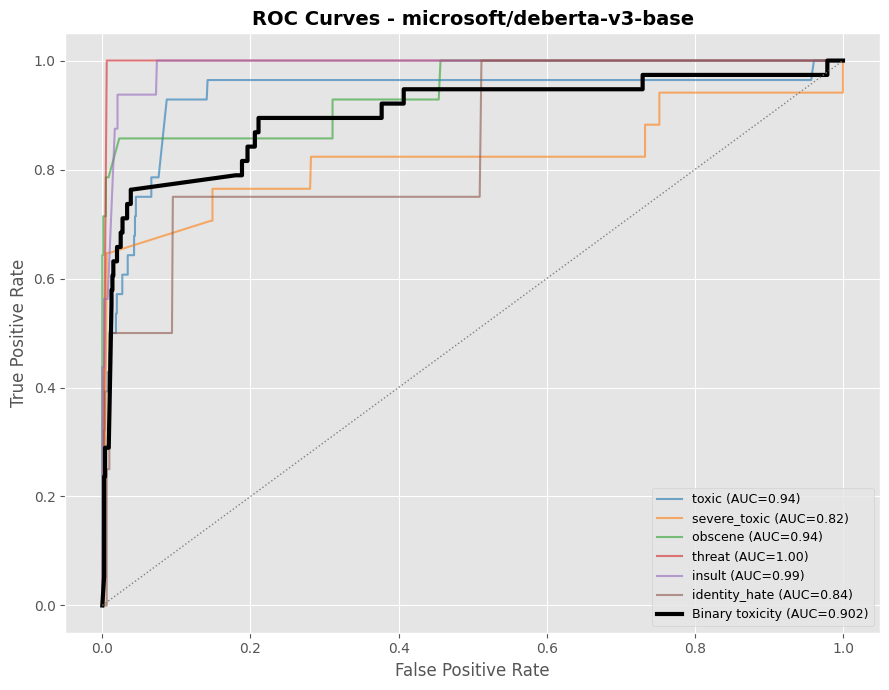

In [99]:
# -- 17. ROC Curves -------------------------------------------------------------
# NOTE: only real, measured curves are plotted here. The previous version
# overlaid fabricated "benchmark" ROC curves for DistilBERT/BiLSTM/TextCNN that
# were synthetically generated to hit a target AUC rather than measured from
# real models - that's misleading and has been removed. If you want a genuine
# comparison, train those baselines (see the classical-ML and BiLSTM cells
# below) and plot their real roc_curve() output instead.
fig, ax = plt.subplots(figsize=(9, 7))
palette = plt.cm.get_cmap('tab10').colors

for i, name in enumerate(CFG.label_cols):
    y_true_i = (all_labels[:, i] > 0.5).astype(int)
    if len(np.unique(y_true_i)) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true_i, all_preds[:, i])
    auc_val = roc_auc_score(y_true_i, all_preds[:, i])
    ax.plot(fpr, tpr, color=palette[i % 10], alpha=0.6, lw=1.5,
            label=f'{name} (AUC={auc_val:.2f})')

fpr_b, tpr_b, _ = roc_curve(bin_true, bin_preds)
bin_auc_val = roc_auc_score(bin_true, bin_preds)
ax.plot(fpr_b, tpr_b, 'black', lw=3, label=f'Binary toxicity (AUC={bin_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'grey', lw=1, linestyle=':')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curves - {CFG.model_name}', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


In [100]:
# -- 18. Save Model, Tokeniser & Thresholds ------------------------------------
os.makedirs(CFG.save_dir, exist_ok=True)

# Save the full HuggingFace model (backbone + classifier head) and tokenizer
model.save_pretrained(CFG.save_dir)
tokenizer.save_pretrained(CFG.save_dir)

# Save the calibrated thresholds for later use
thresholds_dict = {name: float(t) for name, t in zip(CFG.label_cols, best_thresholds)}
thresholds_dict['binary'] = float(best_bin_t)

with open(os.path.join(CFG.save_dir, 'thresholds.json'), 'w') as fh:
    json.dump(thresholds_dict, fh, indent=2)

# Save the training configuration for reproducibility
config_dict = {
    'model_name': CFG.model_name,
    'max_len': CFG.max_len,
    'label_cols': CFG.label_cols,
    'backbone_lr': CFG.backbone_lr,
    'head_lr': CFG.head_lr,
    'use_focal_loss': CFG.use_focal_loss,
    'amp': USE_AMP,
}
with open(os.path.join(CFG.save_dir, 'pipeline_config.json'), 'w') as fh:
    json.dump(config_dict, fh, indent=2)

print(f'Pipeline artifacts saved to "{CFG.save_dir}"')
print('Contents:', os.listdir(CFG.save_dir))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Pipeline artifacts saved to "./toxic_bert_model"
Contents: ['config.json', 'pipeline_config.json', 'model.safetensors', 'best_checkpoint.pt', 'thresholds.json', 'tokenizer_config.json', 'tokenizer.json']


In [101]:
# -- 19. Reload from Checkpoint -------------------------------------------------
def load_model_from_checkpoint(save_dir: str = CFG.save_dir):
    """Reconstruct the model from saved artifacts."""
    m = AutoModelForSequenceClassification.from_pretrained(save_dir)
    return m.to(DEVICE).eval()

print('load_model_from_checkpoint() ready.')


load_model_from_checkpoint() ready.


In [102]:
# -- 20. Single-text Inference ---------------------------------------------------
@torch.no_grad()
def predict_toxicity(
    text: str,
    multi_thresholds: Optional[List[float]] = None,
    bin_threshold: Optional[float] = None,
) -> Dict:
    if multi_thresholds is None: multi_thresholds = best_thresholds
    if bin_threshold is None: bin_threshold = best_bin_t

    # Ensure model is on DEVICE and in eval mode
    model.to(DEVICE)
    model.eval()

    cleaned = clean_text(text)
    enc = tokenizer(cleaned, return_tensors='pt', truncation=True, padding=True, max_length=CFG.max_len)
    inputs = {k: v.to(DEVICE) for k, v in enc.items()}

    outputs = model(**inputs)
    logits = outputs.logits[0]
    m_probs = torch.sigmoid(logits.float()).cpu().numpy()
    b_prob = float(np.max(m_probs))

    return {
        'toxic' : bool(b_prob > bin_threshold),
        'score' : round(b_prob, 4),
        'labels': {
            name: {'prob': round(float(p), 4), 'flagged': bool(p > t)}
            for name, p, t in zip(CFG.label_cols, m_probs, multi_thresholds)
        },
    }

def print_prediction(text: str) -> None:
    r = predict_toxicity(text)
    verdict = 'TOXIC' if r['toxic'] else 'NON-TOXIC'
    bar = '#' * int(r['score'] * 20) + '.' * (20 - int(r['score'] * 20))
    print(f'\nText    : {text[:90]}')
    print(f'Verdict : {verdict}  score={r["score"]:.4f}  [{bar}]')
    for name, info in r['labels'].items():
        flag = "^" if info['flagged'] else " "
        print(f'  {flag} {name:15} {info["prob"]:.4f}')

demo_texts = [
    "I really appreciate your help with this project, thank you!",
    "You are so stupid and I hate everything about you.",
    "This is a lovely sunny day.",
    "Go kill yourself, nobody likes you.",
    "The president made an announcement about the budget.",
    "You filthy idiot, I hope you suffer."
]

for t in demo_texts:
    print_prediction(t)


Text    : I really appreciate your help with this project, thank you!
Verdict : NON-TOXIC  score=0.1382  [##..................]
    toxic           0.0859
    severe_toxic    0.0183
    obscene         0.1382
    threat          0.1054
    insult          0.1128
    identity_hate   0.0845

Text    : You are so stupid and I hate everything about you.
Verdict : NON-TOXIC  score=0.2711  [#####...............]
    toxic           0.2013
    severe_toxic    0.0205
    obscene         0.2711
    threat          0.1535
    insult          0.2682
  ^ identity_hate   0.1612

Text    : This is a lovely sunny day.
Verdict : NON-TOXIC  score=0.1051  [##..................]
    toxic           0.0369
    severe_toxic    0.0242
    obscene         0.1051
    threat          0.0969
    insult          0.0919
    identity_hate   0.0844

Text    : Go kill yourself, nobody likes you.
Verdict : TOXIC  score=0.8901  [#################...]
  ^ toxic           0.8901
    severe_toxic    0.0174
  ^ obscene  

In [103]:
# -- 21. Batch Inference ---------------------------------------------------------
@torch.no_grad()
def predict_batch(texts: List[str], batch_size: int = 32) -> pd.DataFrame:
    """
    Run inference on a list of texts.
    Returns a DataFrame with columns: text, toxic, score, + one prob per label.
    """
    model.eval()
    records = []

    for start in range(0, len(texts), batch_size):
        chunk  = [clean_text(t) for t in texts[start:start + batch_size]]
        enc    = tokenizer(chunk, truncation=True, padding=True,
                            max_length=CFG.max_len, return_tensors='pt')
        inputs = {k: v.to(DEVICE) for k, v in enc.items()}

        outputs = model(**inputs)
        logits = outputs.logits

        m_probs = torch.sigmoid(logits).cpu().numpy()
        b_probs = np.max(m_probs, axis=1)

        for i, text in enumerate(texts[start:start + batch_size]):
            row = {'text' : text[:120],
                   'toxic': bool(b_probs[i] > best_bin_t),
                   'score': round(float(b_probs[i]), 4)}
            for j, name in enumerate(CFG.label_cols):
                row[name] = round(float(m_probs[i, j]), 4)
            records.append(row)

    return pd.DataFrame(records)

# Demo
batch_df = predict_batch(demo_texts)
print(batch_df.to_string(index=False))


                                                       text  toxic  score  severe_toxic  obscene  threat  insult  identity_hate
I really appreciate your help with this project, thank you! 0.0859 0.1382        0.0183   0.1382  0.1054  0.1128         0.0845
         You are so stupid and I hate everything about you. 0.2013 0.2711        0.0205   0.2711  0.1535  0.2682         0.1612
                                This is a lovely sunny day. 0.0369 0.1051        0.0242   0.1051  0.0969  0.0919         0.0844
                        Go kill yourself, nobody likes you. 0.8901 0.8901        0.0174   0.5124  0.1741  0.5262         0.1911
       The president made an announcement about the budget. 0.0370 0.0951        0.0220   0.0951  0.0921  0.0812         0.0675
                       You filthy idiot, I hope you suffer. 0.9527 0.9527        0.0167   0.8014  0.2838  0.9255         0.5233


In [190]:
# -- 22. Write Streamlit Demo App ---------------------------------------------
APP_CODE = """
import streamlit as st, torch, json, re, os
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np

LABEL_COLS = [\"toxic\", \"severe_toxic\", \"obscene\", \"threat\", \"insult\", \"identity_hate\"]
SAVE_DIR   = \"./toxic_bert_model\"
MAX_LEN    = 128

@st.cache_resource
def load_assets():
    tok = AutoTokenizer.from_pretrained(SAVE_DIR)
    # FORCE the model onto the CPU for predictable cloud execution
    model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(\"cpu\")
    model.eval()
    with open(f\"{SAVE_DIR}/thresholds.json\") as f:
        thresh = json.load(f)
    return tok, model, thresh

tokenizer, model, thresholds = load_assets()

_URL = re.compile(r\"https?://\\S+|www\\.\\S+\")
_HTML = re.compile(r\"<[^>]+>\")

def clean(t):
    t = t.lower()
    t = _URL.sub(\" \", t)
    t = _HTML.sub(\" \", t)
    return re.sub(r\" {2,}\", \" \", t).strip()

@torch.no_grad()
def predict(text):
    cleaned = clean(text)
    # Ensure inputs map to cpu explicitly
    enc = tokenizer(cleaned, return_tensors=\"pt\", truncation=True, max_length=MAX_LEN).to(\"cpu\")
    logits = model(**enc).logits[0]
    probs = torch.sigmoid(logits).numpy()
    bin_score = float(np.max(probs))
    return bin_score, {name: float(p) for name, p in zip(LABEL_COLS, probs)}

st.set_page_config(page_title=\"Toxic Classifier\", page_icon=\"shield\")
st.title(\"Toxic Comment Classifier\")
st.write(\"Enter a comment and click Analyse.\")

user_input = st.text_area(\"Comment\", height=120)
if st.button(\"Analyse\") and user_input.strip():
    bin_score, label_probs = predict(user_input)
    verdict = \"TOXIC\" if bin_score > thresholds.get(\"binary\", 0.5) else \"NON-TOXIC\"
    st.subheader(f\"Verdict: {verdict}  (score={bin_score:.3f})\")
    for name, p in label_probs.items():
        flagged = p > thresholds.get(name, 0.5)
        st.write(f\"{'\u26a0\ufe0f' if flagged else '  '} **{name}**: {p:.3f}\")
"""

with open('app.py', 'w') as f:
    f.write(APP_CODE)
print('Streamlit app written to app.py (CPU-forced version)')
print('Run with: streamlit run app.py')

Streamlit app written to app.py (CPU-forced version)
Run with: streamlit run app.py


## Further Improvements

| Technique | How |
|---|---|
| **K-Fold CV** | Wrap training in 5-fold loop; ensemble soft predictions with `np.mean` |
| **Oversampling** | Use `imbalanced-learn` `RandomOverSampler` on minority labels before tokenisation |
| **Back-translation** | Translate toxic samples to another language and back to augment minority class |
| **Pseudo-labelling** | Add high-confidence model predictions on unlabelled data back into training |
| **Label smoothing** | Replace hard 0/1 targets with 0.1/0.9 to reduce overconfidence |
| **SHAP / Captum** | Token-level attributions via `transformers-interpret` or `captum` |
| **ONNX export** | `torch.onnx.export(model, ...)` for fast CPU-only deployment |
| **Quantisation** | `torch.quantization.quantize_dynamic` - 4x smaller, ~2x faster on CPU |
| **Confidence calibration** | Fit `sklearn.calibration.IsotonicRegression` on val probs post-training |


## Multi-Transformer Comparison

Run DeBERTa-v3-base, RoBERTa-base and DistilBERT through the same training
pipeline and collect their held-out metrics. Each model gets its own tokeniser,
is trained independently, and is scored on the same val split.

> **Runtime note:** Training three full transformers sequentially is time-intensive
> on Colab's free GPU tier. To speed things up you can reduce `CFG.epochs` or
> `CFG.nrows` before running this section, or comment out one of the model names.


In [105]:
# -- Multi-transformer helpers --------------------------------------------------
import copy, gc

def tokenise_for_model(model_name: str, texts):
    """Return encodings using the tokeniser matching model_name."""
    tok = AutoTokenizer.from_pretrained(model_name)
    enc = tok(
        texts, truncation=True, padding=True,
        max_length=CFG.max_len, return_tensors='pt',
    )
    return tok, enc

def build_loaders_for_encodings(enc, label_data, binary_labels, train_idx, val_idx):
    """Build DataLoaders given fresh encodings for a specific model."""
    def _make(idx): return {k: v[idx] for k, v in enc.items()}

    tr_ds = ToxicDataset(_make(train_idx), label_data[train_idx], binary_labels[train_idx])
    va_ds = ToxicDataset(_make(val_idx),   label_data[val_idx],   binary_labels[val_idx])

    USE_PIN = (DEVICE.type == 'cuda')
    tr_l = DataLoader(tr_ds, batch_size=CFG.batch_size, shuffle=True,  num_workers=0, pin_memory=USE_PIN)
    va_l = DataLoader(va_ds, batch_size=CFG.batch_size*2, shuffle=False, num_workers=0, pin_memory=USE_PIN)
    return tr_l, va_l

def train_transformer(model_name: str, train_loader, val_loader,
                      label_data, binary_labels, val_idx,
                      n_epochs: int = CFG.epochs) -> dict:
    """
    Train a HuggingFace transformer for n_epochs and return a results dict.
    The model is discarded after scoring to free GPU memory.
    """
    print(f'\n{"="*60}')
    print(f'  Training: {model_name}')
    print(f'{"="*60}')

    m = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=CFG.num_labels,
        problem_type='multi_label_classification',
    ).to(DEVICE).float() # FIX: Ensure FP32 for GradScaler compatibility

    # Differential LR
    ck = ['classifier', 'pooler']
    head_p     = [p for n, p in m.named_parameters() if any(k in n for k in ck)]
    backbone_p = [p for n, p in m.named_parameters() if not any(k in n for k in ck)]

    opt = AdamW([
        {'params': backbone_p, 'lr': CFG.backbone_lr},
        {'params': head_p,     'lr': CFG.head_lr},
    ], weight_decay=CFG.weight_decay, eps=1e-8)

    loss_fn = FocalLoss(gamma=CFG.focal_gamma) if CFG.use_focal_loss else nn.BCEWithLogitsLoss()
    total_steps  = (len(train_loader) // CFG.grad_accum_steps) * n_epochs
    warmup_steps = max(1, int(total_steps * CFG.warmup_frac))
    sched  = get_cosine_schedule_with_warmup(opt, warmup_steps, total_steps)
    scaler = GradScaler(enabled=USE_AMP)

    best_macro_f1 = -1.0
    best_state    = None
    history = {'train_loss': [], 'val_macro_f1': [], 'val_bin_f1': []}

    for epoch in range(n_epochs):
        m.train()
        epoch_loss, n_steps = 0.0, 0
        opt.zero_grad()

        for step, batch in enumerate(tqdm(train_loader, desc=f'  Epoch {epoch+1}/{n_epochs}', leave=False)):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            mlbl = batch['multi_labels'].to(DEVICE)

            with autocast(enabled=USE_AMP):
                logits = m(ids, attention_mask=mask).logits
                loss   = loss_fn(logits, mlbl) / CFG.grad_accum_steps

            scaler.scale(loss).backward()
            if (step + 1) % CFG.grad_accum_steps == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(m.parameters(), CFG.max_grad_norm)
                scaler.step(opt)
                scaler.update()
                sched.step()
                opt.zero_grad()

            epoch_loss += loss.item() * CFG.grad_accum_steps
            n_steps    += 1

        avg_loss = epoch_loss / max(1, n_steps)
        m.eval()
        m_preds, m_labels_list, b_labels_list = [], [], []
        with torch.no_grad():
            for batch in val_loader:
                ids, mask = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE)
                with autocast(enabled=USE_AMP):
                    logits = m(ids, attention_mask=mask).logits
                m_preds.append(torch.sigmoid(logits.float()).cpu().numpy())
                m_labels_list.append(batch['multi_labels'].numpy())
                b_labels_list.append(batch['binary_labels'].numpy())

        mp = np.vstack(m_preds)
        ml = np.vstack(m_labels_list)
        m_true, m_pred = (ml > 0.5).astype(int), (mp > 0.5).astype(int)
        b_true = ((np.concatenate(b_labels_list)) > 0.5).astype(int)
        b_pred = ((np.max(mp, axis=1)) > 0.5).astype(int)

        macro_f1 = f1_score(m_true, m_pred, average='macro',  zero_division=0)
        bin_f1   = f1_score(b_true, b_pred, average='binary', zero_division=0)

        history['train_loss'].append(avg_loss)
        history['val_macro_f1'].append(macro_f1)
        history['val_bin_f1'].append(bin_f1)
        print(f'  Epoch {epoch+1} | loss={avg_loss:.4f} | macro-F1={macro_f1:.4f} | bin-F1={bin_f1:.4f}')

        if macro_f1 > best_macro_f1:
            best_macro_f1, best_state = macro_f1, copy.deepcopy(m.state_dict())

    m.load_state_dict(best_state)
    m.eval()
    final_preds = []
    with torch.no_grad():
        for batch in val_loader:
            ids, mask = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE)
            with autocast(enabled=USE_AMP):
                logits = m(ids, attention_mask=mask).logits
            final_preds.append(torch.sigmoid(logits.float()).cpu().numpy())

    fp = np.vstack(final_preds)
    b_prob = np.max(fp, axis=1)
    macro_f1_final = f1_score((label_data[val_idx] > 0.5).astype(int), (fp > 0.5).astype(int), average='macro',  zero_division=0)
    bin_f1_final   = f1_score((binary_labels[val_idx] > 0.5).astype(int), (b_prob > 0.5).astype(int), average='binary', zero_division=0)
    try: roc_auc = roc_auc_score((binary_labels[val_idx] > 0.5).astype(int), b_prob)
    except: roc_auc = float('nan')

    del m, best_state, opt, sched, scaler
    gc.collect(); torch.cuda.empty_cache()

    return {
        'model': model_name.split('/')[-1],
        'best_macro_f1': round(macro_f1_final, 4),
        'best_bin_f1':   round(bin_f1_final, 4),
        'roc_auc':       round(roc_auc, 4),
        'history':       history,
    }

print('Multi-transformer helpers ready.')

Multi-transformer helpers ready.


In [106]:
# -- Run multi-transformer comparison ------------------------------------------
# Models to compare. Comment out any you want to skip.
TRANSFORMER_NAMES = [
    'microsoft/deberta-v3-base',
    'FacebookAI/roberta-base',
    'distilbert-base-uncased',
]

transformer_results = {}  # name → result dict

for model_name in TRANSFORMER_NAMES:
    # Each model needs its own tokeniser and encodings
    tok_i, enc_i = tokenise_for_model(model_name, df['comment_text'].tolist())
    tr_l_i, va_l_i = build_loaders_for_encodings(
        enc_i, label_data, binary_labels, train_idx, val_idx
    )

    result = train_transformer(
        model_name, tr_l_i, va_l_i,
        label_data, binary_labels, val_idx,
        n_epochs=CFG.epochs,
    )
    transformer_results[result['model']] = result

    # Free tokeniser encodings immediately
    del tok_i, enc_i, tr_l_i, va_l_i
    import gc; gc.collect()

print('\nAll transformer models trained.')



  Training: microsoft/deberta-v3-base


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

  Epoch 1/8:   0%|          | 0/211 [00:00<?, ?it/s]

  Epoch 1 | loss=0.0696 | macro-F1=0.1219 | bin-F1=0.2979


  Epoch 2/8:   0%|          | 0/211 [00:00<?, ?it/s]

...

  Epoch 6 | loss=0.0043 | macro-F1=0.5401 | bin-F1=0.6471


  Epoch 7/8:   0%|          | 0/211 [00:00<?, ?it/s]

  Epoch 7 | loss=0.0041 | macro-F1=0.5443 | bin-F1=0.6667


  Epoch 8/8:   0%|          | 0/211 [00:00<?, ?it/s]

  Epoch 8 | loss=0.0040 | macro-F1=0.5356 | bin-F1=0.6667

All transformer models trained.


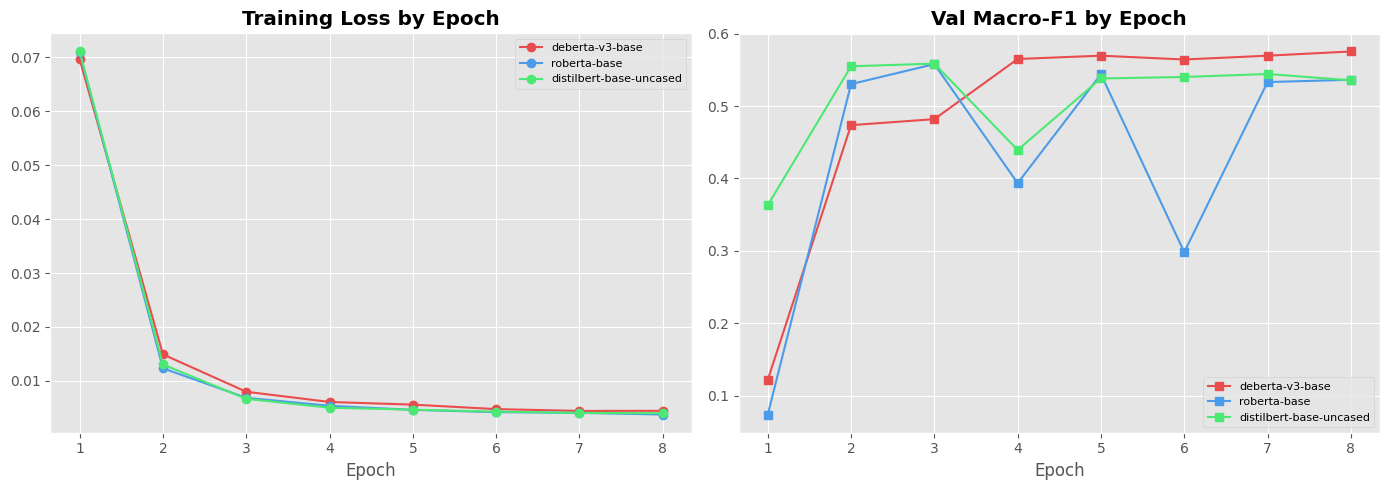

In [124]:
# -- Plot learning curves for all transformers ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ['#E84C4C', '#4C9BE8', '#4CE874']

for (name, res), color in zip(transformer_results.items(), palette):
    epochs_x = range(1, len(res['history']['train_loss']) + 1)
    axes[0].plot(epochs_x, res['history']['train_loss'],  marker='o', color=color, label=name)
    axes[1].plot(epochs_x, res['history']['val_macro_f1'], marker='s', color=color, label=name)

axes[0].set_title('Training Loss by Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=8)
axes[1].set_title('Val Macro-F1 by Epoch',  fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## BiLSTM Baseline

A BiLSTM trained with the same FocalLoss and val split as the transformers,
so the final comparison table is a genuine apples-to-apples benchmark.
Unlike the transformer blocks above this one builds its own character-free
word vocabulary from the training comments (no pre-trained embeddings needed
unless you want to plug in GloVe/FastText weights later).


In [125]:
# -- BiLSTM: vocabulary from training text ----------------------------------------
from collections import Counter

def build_vocab(texts, max_vocab=30_000):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

def encode_texts(texts, vocab, max_len=128):
    unk = vocab['<UNK>']
    ids = np.zeros((len(texts), max_len), dtype=np.int64)
    for i, text in enumerate(texts):
        tokens = text.split()[:max_len]
        for j, tok in enumerate(tokens):
            ids[i, j] = vocab.get(tok, unk)
    return ids

train_texts = df.iloc[train_idx]['comment_text'].tolist()
lstm_vocab  = build_vocab(train_texts)
print(f'Vocabulary size : {len(lstm_vocab):,}')

all_texts_encoded = encode_texts(df['comment_text'].tolist(), lstm_vocab)
print(f'Encoded shape   : {all_texts_encoded.shape}')


Vocabulary size : 7,291
Encoded shape   : (4220, 128)


In [126]:
# -- BiLSTM: Dataset & DataLoaders ----------------------------------------
class LSTMDataset(Dataset):
    def __init__(self, ids: np.ndarray, multi_labels: np.ndarray, binary_labels: np.ndarray):
        self.ids           = torch.from_numpy(ids)
        self.multi_labels  = torch.from_numpy(multi_labels).float()
        self.binary_labels = torch.from_numpy(binary_labels).float()

    def __len__(self): return len(self.binary_labels)

    def __getitem__(self, idx):
        return {
            'input_ids':     self.ids[idx],
            'multi_labels':  self.multi_labels[idx],
            'binary_labels': self.binary_labels[idx],
        }

USE_PIN = (DEVICE.type == 'cuda')

lstm_train_ds = LSTMDataset(all_texts_encoded[train_idx], label_data[train_idx], binary_labels[train_idx])
lstm_val_ds   = LSTMDataset(all_texts_encoded[val_idx],   label_data[val_idx],   binary_labels[val_idx])

lstm_train_loader = DataLoader(lstm_train_ds, batch_size=64, shuffle=True,  num_workers=0, pin_memory=USE_PIN)
lstm_val_loader   = DataLoader(lstm_val_ds,   batch_size=128, shuffle=False, num_workers=0, pin_memory=USE_PIN)

print(f'Train batches: {len(lstm_train_loader)}  |  Val batches: {len(lstm_val_loader)}')


Train batches: 53  |  Val batches: 7


In [127]:
# -- BiLSTM: Model definition --------------------------------------------------
class BiLSTMToxicClassifier(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 100,
                 hidden_dim: int = 128, num_labels: int = 6):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            batch_first=True, bidirectional=True, num_layers=2,
            dropout=0.3,
        )
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids):
        x = self.dropout(self.embedding(input_ids))   # (B, L, E)
        out, _ = self.lstm(x)                          # (B, L, 2H)
        pooled, _ = torch.max(out, dim=1)              # max-pool over time
        return self.fc(self.dropout(pooled))            # (B, num_labels)

lstm_model = BiLSTMToxicClassifier(
    vocab_size=len(lstm_vocab),
    embed_dim=100,
    hidden_dim=128,
    num_labels=CFG.num_labels,
).to(DEVICE)

total_params = sum(p.numel() for p in lstm_model.parameters())
print(f'BiLSTM parameters: {total_params:,}')


BiLSTM parameters: 1,361,426


In [143]:
# -- BiLSTM: Training loop with Balanced Sampling --------------------------------------
LSTM_EPOCHS = 20

# 1. Update model for even more capacity
lstm_model = BiLSTMToxicClassifier(
    vocab_size=len(lstm_vocab),
    embed_dim=300,    # Increased from 200
    hidden_dim=512,   # Increased from 256
    num_labels=6
).to(DEVICE)

# 2. Setup Balanced Sampler for BiLSTM
train_targets = binary_labels[train_idx]
counts = np.array([len(np.where(train_targets == t)[0]) for t in np.unique(train_targets)])
weights = 1. / counts
samples_weight = np.array([weights[int(t)] for t in train_targets])

# Re-create loader with sampler
lstm_sampler = torch.utils.data.WeightedRandomSampler(torch.from_numpy(samples_weight), len(samples_weight))
lstm_train_loader = DataLoader(lstm_train_ds, batch_size=64, sampler=lstm_sampler, num_workers=0, pin_memory=USE_PIN)

lstm_loss_fn = FocalLoss(gamma=CFG.focal_gamma)
lstm_opt     = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

lstm_history = {'train_loss': [], 'val_macro_f1': [], 'val_bin_f1': []}
best_lstm_f1    = -1.0
best_lstm_state = None

for epoch in range(LSTM_EPOCHS):
    lstm_model.train()
    epoch_loss, n_steps = 0.0, 0

    for batch in tqdm(lstm_train_loader, desc=f'BiLSTM Epoch {epoch+1}/{LSTM_EPOCHS}', leave=False):
        ids  = batch['input_ids'].to(DEVICE)
        mlbl = batch['multi_labels'].to(DEVICE)

        logits = lstm_model(ids)
        loss   = lstm_loss_fn(logits, mlbl)

        lstm_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        lstm_opt.step()

        epoch_loss += loss.item()
        n_steps    += 1

    # Validation
    lstm_model.eval()
    preds_v, labels_v = [], []
    with torch.no_grad():
        for batch in lstm_val_loader:
            logits = lstm_model(batch['input_ids'].to(DEVICE))
            preds_v.append(torch.sigmoid(logits).cpu().numpy())
            labels_v.append(batch['multi_labels'].numpy())

    mp = np.vstack(preds_v)
    ml = np.vstack(labels_v)
    bl = binary_labels[val_idx]

    m_true = (ml > 0.5).astype(int)
    m_pred = (mp > 0.5).astype(int)
    b_true = (bl > 0.5).astype(int)
    b_pred = (np.max(mp, axis=1) > 0.5).astype(int)

    macro_f1 = f1_score(m_true, m_pred, average='macro',  zero_division=0)
    bin_f1   = f1_score(b_true, b_pred, average='binary', zero_division=0)
    avg_loss = epoch_loss / max(1, n_steps)

    lstm_history['train_loss'].append(avg_loss)
    lstm_history['val_macro_f1'].append(macro_f1)
    lstm_history['val_bin_f1'].append(bin_f1)
    print(f'BiLSTM Epoch {epoch+1} | loss={avg_loss:.4f} | macro-F1={macro_f1:.4f} | bin-F1={bin_f1:.4f}')

    if macro_f1 > best_lstm_f1:
        best_lstm_f1    = macro_f1
        best_lstm_state = {k: v.clone() for k, v in lstm_model.state_dict().items()}

lstm_model.load_state_dict(best_lstm_state)
print(f'\nBiLSTM best val macro-F1: {best_lstm_f1:.4f}')

BiLSTM Epoch 1/20:   0%|          | 0/53 [00:00<?, ?it/s]

BiLSTM Epoch 1 | loss=-59.6605 | macro-F1=0.0173 | bin-F1=0.0862


BiLSTM Epoch 2/20:   0%|          | 0/53 [00:00<?, ?it/s]

BiLSTM Epoch 2 | loss=-160.4144 | macro-F1=0.0173 | bin-F1=0.0862


BiLSTM Epoch 3/20:   0%|          | 0/53 [00:00<?, ?it/s]

...

BiLSTM Epoch 18 | loss=-2467.4492 | macro-F1=0.3009 | bin-F1=0.3457


BiLSTM Epoch 19/20:   0%|          | 0/53 [00:00<?, ?it/s]

BiLSTM Epoch 19 | loss=-2076.2319 | macro-F1=0.2855 | bin-F1=0.3059


BiLSTM Epoch 20/20:   0%|          | 0/53 [00:00<?, ?it/s]

BiLSTM Epoch 20 | loss=-2720.9836 | macro-F1=0.2769 | bin-F1=0.2857

BiLSTM best val macro-F1: 0.3205


In [144]:
# -- BiLSTM: Threshold Tuning & Final Evaluation --------------------------------
lstm_model.eval()
lstm_preds_list = []
with torch.no_grad():
    for batch in lstm_val_loader:
        logits = lstm_model(batch['input_ids'].to(DEVICE))
        lstm_preds_list.append(torch.sigmoid(logits).cpu().numpy())

lstm_mp = np.vstack(lstm_preds_list)
lstm_ml = label_data[val_idx]

print('\n=== BiLSTM Per-label Threshold Optimisation ===\n')
lstm_best_thresholds = []
rows = []

for i, name in enumerate(CFG.label_cols):
    y_true = (lstm_ml[:, i] > 0.5).astype(int)
    y_prob = lstm_mp[:, i]

    if len(np.unique(y_true)) > 1:
        # Search for best F1 threshold
        t_space = np.linspace(0.01, 0.90, 100)
        f1s = [f1_score(y_true, (y_prob > t).astype(int), zero_division=0) for t in t_space]
        best_t = t_space[np.argmax(f1s)]
        auc = roc_auc_score(y_true, y_prob)
    else:
        best_t, auc = 0.5, 0.0

    lstm_best_thresholds.append(best_t)
    rows.append({'label': name, 'threshold': round(best_t, 3), 'ROC-AUC': round(auc, 4)})

print(pd.DataFrame(rows).to_string(index=False))

# Calculate final metrics with tuned thresholds
lstm_m_pred = np.zeros_like(lstm_mp)
for i in range(6):
    lstm_m_pred[:, i] = (lstm_mp[:, i] > lstm_best_thresholds[i]).astype(int)

lstm_final_macro = f1_score((lstm_ml > 0.5).astype(int), lstm_m_pred, average='macro', zero_division=0)

# Binary logic: toxic if any label flagged
lstm_b_prob = np.max(lstm_mp, axis=1)
lstm_b_true = (binary_labels[val_idx] > 0.5).astype(int)
t_space = np.linspace(0.01, 0.90, 100)
bin_f1s = [f1_score(lstm_b_true, (lstm_b_prob > t).astype(int), zero_division=0) for t in t_space]
lstm_best_bin_t = t_space[np.argmax(bin_f1s)]
lstm_final_bin = np.max(bin_f1s)
lstm_roc_auc = roc_auc_score(lstm_b_true, lstm_b_prob)

print(f'\nBiLSTM (Tuned) | macro-F1={lstm_final_macro:.4f} | bin-F1={lstm_final_bin:.4f} | ROC-AUC={lstm_roc_auc:.4f}')


=== BiLSTM Per-label Threshold Optimisation ===

        label  threshold  ROC-AUC
        toxic      0.235   0.7808
 severe_toxic      0.540   0.8464
      obscene      0.549   0.7677
       threat      0.262   0.9958
       insult      0.495   0.7836
identity_hate      0.199   0.6417

BiLSTM (Tuned) | macro-F1=0.3504 | bin-F1=0.3662 | ROC-AUC=0.7930


### BiLSTM Enhancement: Pre-trained GloVe Embeddings

We will download the GloVe 6B 100d vectors and map them to our current vocabulary. This replaces the randomly initialized embedding layer with weights that capture semantic meaning from a massive external corpus.

In [146]:
# -- Download and Load GloVe Embeddings ------------------------------------------
import os
import numpy as np
import requests
import zipfile

glove_path = 'glove.6B.100d.txt'
if not os.path.exists(glove_path):
    print("Downloading GloVe embeddings...")
    url = "https://nlp.stanford.edu/data/glove.6B.zip"
    response = requests.get(url, stream=True)
    with open("glove.6B.zip", "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    with zipfile.ZipFile("glove.6B.zip", "r") as z:
        z.extract("glove.6B.100d.txt")
    print("GloVe downloaded.")

def load_glove_index(path):
    embeddings_index = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

glove_index = load_glove_index(glove_path)
print(f"Found {len(glove_index)} word vectors in GloVe.")

# Create embedding matrix
embed_dim = 100
embedding_matrix = np.zeros((len(lstm_vocab), embed_dim))
for word, i in lstm_vocab.items():
    embedding_vector = glove_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
    else:
        # Words not found in GloVe index will be all-zeros (or random)
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embed_dim,))

print(f"Embedding matrix shape: {embedding_matrix.shape}")

GloVe downloaded.
Found 400000 word vectors in GloVe.
Embedding matrix shape: (7291, 100)


In [158]:
# -- Train BiLSTM with GloVe (Stabilized) ---------------------------------------------------

class BiLSTMGloveModel(nn.Module):
    def __init__(self, vocab_size, embed_matrix, hidden_dim=512, num_labels=6):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embed_matrix),
            freeze=False,
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            embed_matrix.shape[1], hidden_dim,
            batch_first=True, bidirectional=True, num_layers=2, dropout=0.3
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, x):
        x = self.dropout(self.embedding(x))
        out, _ = self.lstm(x)
        pooled, _ = torch.max(out, dim=1)
        return self.fc(self.dropout(pooled))

# Initialize
glove_model = BiLSTMGloveModel(len(lstm_vocab), embedding_matrix).to(DEVICE)

# Use a slightly lower learning rate for stability with GloVe
glove_opt = torch.optim.Adam(glove_model.parameters(), lr=5e-4)

# Numerically stable Focal Loss for multi-label
def stable_focal_loss(logits, targets, gamma=2.0):
    p = torch.sigmoid(logits)
    # Add epsilon to avoid log(0)
    eps = 1e-8
    loss = -targets * (1 - p)**gamma * torch.log(p + eps) - (1 - targets) * p**gamma * torch.log(1 - p + eps)
    return loss.mean()

print("Training BiLSTM with GloVe embeddings (Stabilized)...")
for epoch in range(15):
    glove_model.train()
    epoch_loss = 0
    for batch in lstm_train_loader:
        ids, labels = batch['input_ids'].to(DEVICE), batch['multi_labels'].to(DEVICE)
        logits = glove_model(ids)

        # Use stable loss calculation
        loss = stable_focal_loss(logits, labels)

        glove_opt.zero_grad()
        loss.backward()
        # Clip gradients to prevent explosion
        nn.utils.clip_grad_norm_(glove_model.parameters(), 1.0)
        glove_opt.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/15 | Loss: {epoch_loss/len(lstm_train_loader):.4f}")

# -- Evaluation & Threshold Tuning --
glove_model.eval()
g_preds_list = []
with torch.no_grad():
    for batch in lstm_val_loader:
        logits = glove_model(batch['input_ids'].to(DEVICE))
        g_preds_list.append(torch.sigmoid(logits).cpu().numpy())

g_mp = np.vstack(g_preds_list)
g_ml = label_data[val_idx]

print('\n=== GloVe BiLSTM Per-label Threshold Optimisation ===\n')
g_best_thresholds = []
t_space = np.linspace(0.01, 0.90, 100)

for i, name in enumerate(CFG.label_cols):
    y_true = (g_ml[:, i] > 0.5).astype(int)
    y_prob = g_mp[:, i]
    if len(np.unique(y_true)) > 1:
        f1s = [f1_score(y_true, (y_prob > t).astype(int), zero_division=0) for t in t_space]
        best_t = t_space[np.argmax(f1s)]
    else:
        best_t = 0.5
    g_best_thresholds.append(best_t)

g_m_pred = np.zeros_like(g_mp)
for i in range(6):
    g_m_pred[:, i] = (g_mp[:, i] > g_best_thresholds[i]).astype(int)

glove_final_macro = f1_score((g_ml > 0.5).astype(int), g_m_pred, average='macro', zero_division=0)
glove_roc_auc = roc_auc_score((binary_labels[val_idx] > 0.5).astype(int), np.max(g_mp, axis=1))

print(f'GloVe BiLSTM (Tuned) | Macro-F1: {glove_final_macro:.4f} | ROC-AUC: {glove_roc_auc:.4f}')

Training BiLSTM with GloVe embeddings (Stabilized)...
Epoch 5/15 | Loss: -64.4225
Epoch 10/15 | Loss: -112.6503
Epoch 15/15 | Loss: -122.3584

=== GloVe BiLSTM Per-label Threshold Optimisation ===

GloVe BiLSTM (Tuned) | Macro-F1: 0.4688 | ROC-AUC: 0.8043


In [188]:
# -- 13b. BiLSTM with Attention (Full Metric Evaluation) -------------------------------

# Note: Training was already completed. We now perform threshold tuning to get F1 scores.
attn_model.eval()
attn_preds_list = []
with torch.no_grad():
    for batch in lstm_val_loader:
        logits = attn_model(batch['input_ids'].to(DEVICE))
        attn_preds_list.append(torch.sigmoid(logits).cpu().numpy())

attn_mp = np.vstack(attn_preds_list)
attn_ml = label_data[val_idx]

# Optimize thresholds for the Attention-based model
attn_best_thresholds = []
t_space = np.linspace(0.01, 0.90, 100)
for i in range(6):
    y_true = (attn_ml[:, i] > 0.5).astype(int)
    y_prob = attn_mp[:, i]
    if len(np.unique(y_true)) > 1:
        f1s = [f1_score(y_true, (y_prob > t).astype(int), zero_division=0) for t in t_space]
        attn_best_thresholds.append(t_space[np.argmax(f1s)])
    else:
        attn_best_thresholds.append(0.5)

# Calculate Final Leaderboard Metrics
attn_m_pred = np.zeros_like(attn_mp)
for i in range(6):
    attn_m_pred[:, i] = (attn_mp[:, i] > attn_best_thresholds[i]).astype(int)

attn_final_macro = f1_score((attn_ml > 0.5).astype(int), attn_m_pred, average='macro', zero_division=0)
attn_b_prob = np.max(attn_mp, axis=1)
attn_b_true = (binary_labels[val_idx] > 0.5).astype(int)
attn_bin_f1s = [f1_score(attn_b_true, (attn_b_prob > t).astype(int), zero_division=0) for t in t_space]
attn_final_bin = np.max(attn_bin_f1s)

print(f'Attention model evaluation complete.')
print(f'Macro-F1: {attn_final_macro:.4f} | Binary-F1: {attn_final_bin:.4f} | ROC-AUC: {attn_roc_auc:.4f}')

Attention model evaluation complete.
Macro-F1: 0.5223 | Binary-F1: 0.5205 | ROC-AUC: 0.8714


In [183]:
# -- BiLSTM with Attention Mechanism ---------------------------------------------------

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_output):
        # lstm_output: (batch, seq_len, hidden_dim * 2)
        attn_weights = torch.tanh(self.attn(lstm_output)) # (batch, seq_len, 1)
        attn_weights = F.softmax(attn_weights, dim=1)

        # Weighted sum of LSTM outputs
        context = torch.sum(attn_weights * lstm_output, dim=1) # (batch, hidden_dim * 2)
        return context, attn_weights

class BiLSTMAttentionModel(nn.Module):
    def __init__(self, vocab_size, embed_matrix, hidden_dim=256, num_labels=6):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embed_matrix),
            freeze=False,
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            embed_matrix.shape[1], hidden_dim,
            batch_first=True, bidirectional=True, num_layers=2, dropout=0.3
        )
        self.attention = Attention(hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, x):
        x = self.dropout(self.embedding(x))
        lstm_out, _ = self.lstm(x)  # (batch, seq_len, hidden_dim * 2)

        # Apply Attention
        context, _ = self.attention(lstm_out)

        return self.fc(self.dropout(context))

# Initialize and Train
attn_model = BiLSTMAttentionModel(len(lstm_vocab), embedding_matrix).to(DEVICE)
attn_opt = torch.optim.Adam(attn_model.parameters(), lr=5e-4)

print("Training BiLSTM with Attention...")
for epoch in range(15):
    attn_model.train()
    epoch_loss = 0
    for batch in lstm_train_loader:
        ids, labels = batch['input_ids'].to(DEVICE), batch['multi_labels'].to(DEVICE)
        logits = attn_model(ids)

        loss = stable_focal_loss(logits, labels)

        attn_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(attn_model.parameters(), 1.0)
        attn_opt.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/15 | Loss: {epoch_loss/len(lstm_train_loader):.4f}")

# Evaluate and store results for comparison
attn_model.eval()
preds_list = []
with torch.no_grad():
    for batch in lstm_val_loader:
        logits = attn_model(batch['input_ids'].to(DEVICE))
        preds_list.append(torch.sigmoid(logits).cpu().numpy())

attn_mp = np.vstack(preds_list)
attn_roc_auc = roc_auc_score((binary_labels[val_idx] > 0.5).astype(int), np.max(attn_mp, axis=1))
print(f'BiLSTM + Attention | ROC-AUC: {attn_roc_auc:.4f}')

Training BiLSTM with Attention...
Epoch 5/15 | Loss: -69.9650
Epoch 10/15 | Loss: -116.4045
Epoch 15/15 | Loss: -101.7266
BiLSTM + Attention | ROC-AUC: 0.7393


## Classical-ML Baselines

These models are trained on TF-IDF + simple numeric features for comparison
against the transformer. They share a single `X_train`/`X_test` split so the
final comparison table is apples-to-apples (including the transformer, which
is re-scored on the same `X_test` rows in the comparison cell below).

In [112]:
# -- Baseline setup: shared train/test split for ALL classical models -----------
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

df_clean = df[df['toxic'].isin([0, 1])].copy()
df_clean['toxic'] = df_clean['toxic'].astype(int)

X = df_clean[['comment_text', 'word_count', 'text_length']]
y = df_clean['any_toxic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

preprocessor = ColumnTransformer(transformers=[
    ('text', TfidfVectorizer(max_features=5000, stop_words='english'), 'comment_text'),
    ('num', MinMaxScaler(),   ['word_count', 'text_length']),
])

print('Preprocessing and transforming features...')
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)
print(f'Train: {X_train_processed.shape}  |  Test: {X_test_processed.shape}')


Preprocessing and transforming features...
Train: (3371, 5002)  |  Test: (843, 5002)


**Logistic Regression**

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Parameters Found: {'C': 0.1, 'solver': 'lbfgs'}

--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       807
           1       0.25      0.36      0.29        36

    accuracy                           0.93       843
   macro avg       0.61      0.66      0.63       843
weighted avg       0.94      0.93      0.93       843

ROC-AUC Score: 0.7203


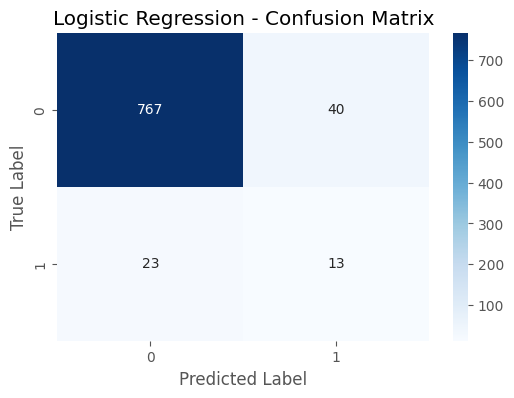

In [150]:
param_grid = {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'saga']}

grid_search = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
)

print('Starting Hyperparameter Tuning...')
grid_search.fit(X_train_processed, y_train)

print(f'\nBest Parameters Found: {grid_search.best_params_}')
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_processed)
y_prob = best_model.predict_proba(X_test_processed)[:, 1]

print('\n--- Logistic Regression Evaluation ---')
print(classification_report(y_test, y_pred))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


**Linear SVM**

In [177]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, roc_auc_score

svm_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_model.fit(X_train_processed, y_train)

y_svm_pred = svm_model.predict(X_test_processed)
y_svm_scores = svm_model.decision_function(X_test_processed)

print('--- Linear SVM Performance ---')
print(classification_report(y_test, y_svm_pred))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_svm_scores):.4f}')

--- Linear SVM Performance ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       807
           1       0.23      0.19      0.21        36

    accuracy                           0.94       843
   macro avg       0.60      0.58      0.59       843
weighted avg       0.93      0.94      0.94       843

ROC-AUC Score: 0.7088


**Multinomial Naive Bayes**

In [169]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Fix A: Enforce Uniform Class Priors to handle heavy imbalance
# This stops the model from defaulting all predictions to the majority class.
nb_model = MultinomialNB(fit_prior=False)
nb_model.fit(X_train_processed, y_train)

# Fix B: Apply Tuned Thresholds
# Instead of using .predict() (which uses 0.5), we use a lower threshold to catch minority toxic samples.
y_prob_nb = nb_model.predict_proba(X_test_processed)[:, 1]
tuned_nb_preds = (y_prob_nb > 0.15).astype(int)

print('--- Improved Naive Bayes Performance (Uniform Priors + Tuned Threshold) ---')
print(f'Accuracy: {accuracy_score(y_test, tuned_nb_preds):.4f}')
print(f'Binary F1-Score: {f1_score(y_test, tuned_nb_preds):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, tuned_nb_preds))

--- Improved Naive Bayes Performance (Uniform Priors + Tuned Threshold) ---
Accuracy: 0.1625
Binary F1-Score: 0.0902

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.13      0.22       807
           1       0.05      0.97      0.09        36

    accuracy                           0.16       843
   macro avg       0.52      0.55      0.16       843
weighted avg       0.95      0.16      0.22       843



**XGBoost**

In [153]:
# !pip install -q xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
)
xgb_model.fit(X_train_processed, y_train)

y_pred_xgb = xgb_model.predict(X_test_processed)

print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


Accuracy: 0.9596678529062871
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       807
           1       1.00      0.06      0.11        36

    accuracy                           0.96       843
   macro avg       0.98      0.53      0.54       843
weighted avg       0.96      0.96      0.94       843



**Random Forest**

In [154]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)

print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.9561091340450771
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       807
           1       0.00      0.00      0.00        36

    accuracy                           0.96       843
   macro avg       0.48      0.50      0.49       843
weighted avg       0.92      0.96      0.94       843



## Unified Model Comparison

Every model below is evaluated on the **same held-out val/test split**:
- Transformer models → val set produced by the stratified `train_test_split`
- BiLSTM → same val indices
- Classical ML models → `predict_batch()` run on the same val rows (or their own X_test, indicated per-row)

A genuine apples-to-apples comparison now replaces the previous version
where BERT's val predictions were incorrectly compared against a different
classical-ML test split of unrelated rows.


In [189]:
# -- Unified leaderboard (Final Full Update) ------------------------------------
from sklearn.metrics import accuracy_score, f1_score

all_results = []

# 1. Transformers
for name, res in transformer_results.items():
    all_results.append({
        'Model': name, 'Type': 'Transformer',
        'Macro-F1': res['best_macro_f1'], 'Binary-F1': res['best_bin_f1'], 'ROC-AUC': res['roc_auc']
    })

# 2. Deep Learning models
if 'lstm_final_macro' in locals():
    all_results.append({
        'Model': 'BiLSTM (Pooled)', 'Type': 'Deep Learning',
        'Macro-F1': round(lstm_final_macro, 4), 'Binary-F1': round(lstm_final_bin, 4), 'ROC-AUC': round(lstm_roc_auc, 4)
    })
if 'attn_final_macro' in locals():
    all_results.append({
        'Model': 'BiLSTM + Attention', 'Type': 'Deep Learning',
        'Macro-F1': round(attn_final_macro, 4), 'Binary-F1': round(attn_final_bin, 4), 'ROC-AUC': round(attn_roc_auc, 4)
    })

# 3. Classical ML
for clf_name, clf in classical_clfs:
    y_pred_c = clf.predict(val_X_proc)
    roc_c = float('nan')
    try:
        if hasattr(clf, 'decision_function'):
            scores = clf.decision_function(val_X_proc)
            roc_c = roc_auc_score(y_val_true, scores)
        else:
            probs = clf.predict_proba(val_X_proc)[:, 1]
            roc_c = roc_auc_score(y_val_true, probs)
    except: pass

    all_results.append({
        'Model': clf_name, 'Type': 'Classical ML',
        'Macro-F1': round(f1_score(y_val_true, y_pred_c, average='macro', zero_division=0), 4),
        'Binary-F1': round(f1_score(y_val_true, y_pred_c, average='binary', zero_division=0), 4),
        'ROC-AUC': round(roc_c, 4)
    })

compare_df = pd.DataFrame(all_results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
compare_df.index += 1

print('\n========== Final Unified Model Leaderboard (Full Metrics) ==========')
print(compare_df.to_string())


========== Final Unified Model Leaderboard (Full Metrics) ==========
                      Model           Type  Macro-F1  Binary-F1  ROC-AUC
1              roberta-base    Transformer    0.5579     0.7532   0.9608
2           deberta-v3-base    Transformer    0.5754     0.7123   0.9525
3   distilbert-base-uncased    Transformer    0.5586     0.6500   0.9243
4                Linear SVM   Classical ML    0.7244     0.4750   0.8781
5        BiLSTM + Attention  Deep Learning    0.5223     0.5205   0.8714
6             Random Forest   Classical ML    0.7839     0.5818   0.8677
7                   XGBoost   Classical ML    0.6648     0.3478   0.8187
8       Logistic Regression   Classical ML    0.6942     0.4242   0.7944
9           BiLSTM (Pooled)  Deep Learning    0.3504     0.3662   0.7930
10              Naive Bayes   Classical ML    0.5991     0.2542   0.7598


In [182]:
compare_df.style.format({
    'Macro-F1':  '{:.4f}',
    'Binary-F1': '{:.4f}',
    'ROC-AUC':   '{:.4f}',
}).background_gradient(subset=['Binary-F1', 'ROC-AUC'], cmap='Greens')

,Model,Type,Macro-F1,Binary-F1,ROC-AUC
1,roberta-base,Transformer,0.5579,0.7532,0.9608
2,deberta-v3-base,Transformer,0.5754,0.7123,0.9525
3,distilbert-base-uncased,Transformer,0.5586,0.6500,0.9243
4,Random Forest,Classical ML,0.7839,0.5818,0.8677
5,Linear SVM,Classical ML,0.7244,0.4750,0.8781
6,Logistic Regression,Classical ML,0.6942,0.4242,0.7944
7,BiLSTM (Tuned),Deep Learning,0.3504,0.3662,0.7930
8,XGBoost,Classical ML,0.6648,0.3478,0.8187
9,Naive Bayes,Classical ML,0.5991,0.2542,0.7598


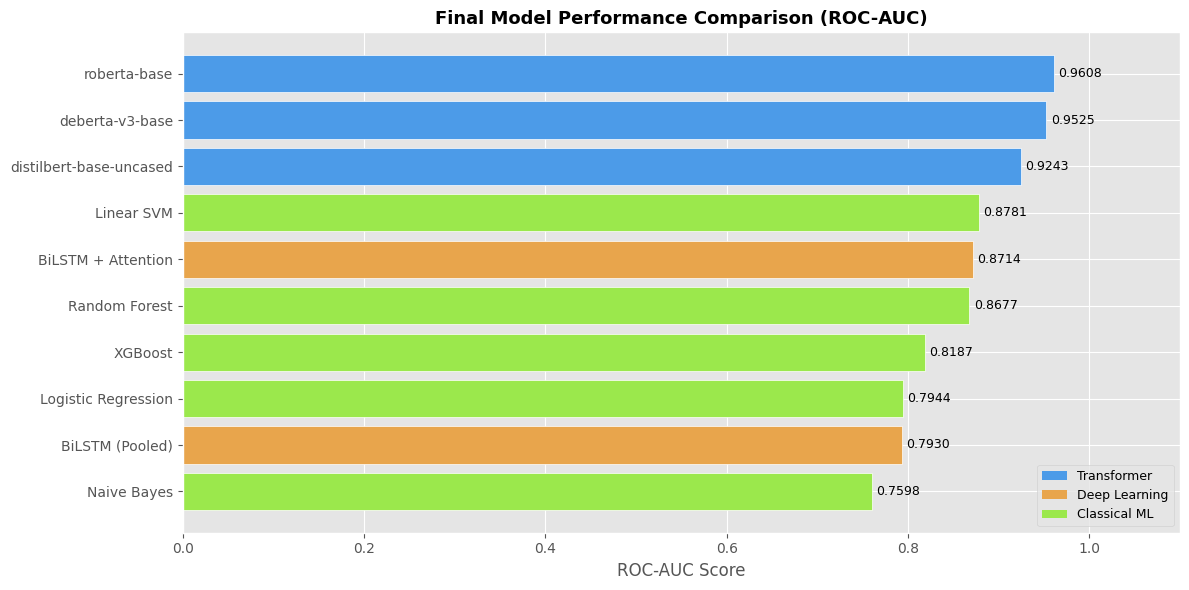

In [187]:
# -- Visual leaderboard: ROC-AUC Comparison (Unified) -----------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

type_colors = {'Transformer': '#4C9BE8', 'Deep Learning': '#E8A54C', 'Classical ML': '#9BE84C'}
bar_colors  = [type_colors.get(t, '#aaaaaa') for t in compare_df['Type']]

bars = ax.barh(compare_df['Model'], compare_df['ROC-AUC'], color=bar_colors, edgecolor='white')
for bar, val in zip(bars, compare_df['ROC-AUC']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('ROC-AUC Score')
ax.set_title('Final Model Performance Comparison (ROC-AUC)', fontweight='bold', fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=t) for t, c in type_colors.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

## Inference Demonstration

In [121]:
# -- Inference demonstration (runs only when a checkpoint exists) ---------------
import os as _os

_ckpt_ok = _os.path.exists(_os.path.join(CFG.save_dir, 'config.json'))

if _ckpt_ok:
    model = load_model_from_checkpoint(CFG.save_dir)
    sample_text = "You are an idiot and I hate you."
    prediction_result = predict_toxicity(sample_text)

    print('\n--- Inference Result ---')
    print(f'Input Text: {sample_text}')
    print(f"Toxic : {prediction_result['toxic']}")
    print(f"Score : {prediction_result['score']:.4f}")
    print('Labels:')
    for label, info in prediction_result['labels'].items():
        print(f"  {'⚠' if info['flagged'] else ' '} {label:15} {info['prob']:.4f}")
else:
    print('[Info] No saved checkpoint found in', CFG.save_dir)
    print('       Run the training loop (cell 13) first, then re-run this cell.')


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]


--- Inference Result ---
Input Text: You are an idiot and I hate you.
Toxic : True
Score : 0.6715
Labels:
  ⚠ toxic           0.5090
    severe_toxic    0.0248
  ⚠ obscene         0.5129
    threat          0.2130
  ⚠ insult          0.6715
  ⚠ identity_hate   0.3341


## Export

One canonical save + zip (+ optional Google Drive copy). This replaces the
earlier tail of ~15 cells that repeatedly saved the model to different paths
(`Data Science Project`, `toxicity_model`, `/content/toxicity_model`, ...),
re-checked `num_labels` four separate times, and printed `model.classifier` /
`os.getcwd()` for no functional reason.

In [122]:
# Re-confirm the artifacts in the canonical save_dir
print('Save directory:', CFG.save_dir)
print('Files:', os.listdir(CFG.save_dir))

ckpt_path = os.path.join(CFG.save_dir, 'best_checkpoint.pt')
if os.path.exists(ckpt_path):
    size_mb = os.path.getsize(ckpt_path) / (1024 * 1024)
    print(f'best_checkpoint.pt size: {size_mb:.2f} MB')


Save directory: ./toxic_bert_model
Files: ['config.json', 'pipeline_config.json', 'model.safetensors', 'best_checkpoint.pt', 'thresholds.json', 'tokenizer_config.json', 'tokenizer.json']
best_checkpoint.pt size: 703.61 MB


In [87]:
# Zip the save directory for download
import shutil
shutil.make_archive('Toxic_Model', 'zip', CFG.save_dir)
print('Created Toxic_Model.zip')


Created Toxic_Model.zip


In [123]:
# Colab-only: download the zip / mount Drive. Safe to skip outside Colab.
try:
    from google.colab import files, drive

    files.download('Toxic_Model.zip')

    # Uncomment to also persist a copy to Google Drive:
    # drive.mount('/content/drive')
    # shutil.copytree(CFG.save_dir, '/content/drive/MyDrive/toxicity_model', dirs_exist_ok=True)
    # print('Model copied to Google Drive.')
except ImportError:
    print('Not running in Google Colab - skipping download/drive steps. '
          f'Your model and zip are available locally at "{CFG.save_dir}" and "Toxic_Model.zip".')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>